# Negotiating the Past - Local Classification with MLX

This notebook uses **Ministral-3-14B-Instruct** running locally on Apple Silicon via MLX to classify prompts that contain references to the past.

**Hardware requirements**: Mac with Apple Silicon (M1/M2/M3/M4) and at least 16GB unified memory (32GB+ recommended for 14B model).

## 1. Setup & Dependencies

In [1]:
# Install dependencies -- uncomment to install
#%pip install mlx-lm pandas tqdm huggingface_hub

In [2]:
import os
import time
import logging
import json
import re
from datetime import datetime
from pathlib import Path

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# Create directories
os.makedirs("data/results_mlx", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# Setup logging - save to logs folder
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(f"logs/mlx_classification_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger("mlx_classifier")

print("Libraries loaded successfully")

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries loaded successfully


## 1b. Data Exploration - Modifiers Statistics

Explore the `modifiers` field from the raw_data JSON to understand what keywords are most common in the dataset.

In [3]:
# Explore modifiers from the raw_data JSON
# Sample 50,000 rows for statistics (parsing JSON is slow on full dataset)

EXPLORATION_SAMPLE_SIZE = 50_000

print(f"Loading {EXPLORATION_SAMPLE_SIZE:,} rows with full metadata for exploration...")

# Count total rows
total_rows = sum(1 for _ in open('data/prompts.csv')) - 1
print(f"Total rows in dataset: {total_rows:,}")

# Random sample
skip_prob = 1 - EXPLORATION_SAMPLE_SIZE / total_rows
np.random.seed(42)

sample_df = pd.read_csv(
    'data/prompts.csv',
    skiprows=lambda x: x > 0 and np.random.random() < skip_prob,
    nrows=EXPLORATION_SAMPLE_SIZE
)

print(f"Loaded {len(sample_df):,} rows")
print(f"Columns: {list(sample_df.columns)}")

Loading 50,000 rows with full metadata for exploration...
Total rows in dataset: 10,789,407
Loaded 49,793 rows
Columns: ['prompt', 'raw_data']


In [4]:
# Parse raw_data JSON and extract metadata
from collections import Counter

def parse_raw_data(raw_data_str):
    """Parse the raw_data JSON string and extract key fields."""
    try:
        data = json.loads(raw_data_str)
        discord_data = data.get('raw_discord_data', {})
        return {
            'modifiers': data.get('modifiers', []),
            'image_uri': discord_data.get('image_uri', ''),
            'timestamp': discord_data.get('timestamp', 0),
            'width': discord_data.get('width', 0),
            'height': discord_data.get('height', 0),
            'num_step': discord_data.get('num_step', 0),
            'cfg_scale': discord_data.get('cfg_scale', 0),
        }
    except (json.JSONDecodeError, TypeError):
        return None

# Parse all rows
print("Parsing JSON metadata...")
parsed_data = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Parsing"):
    parsed = parse_raw_data(row['raw_data'])
    if parsed:
        parsed['prompt'] = row['prompt']
        parsed_data.append(parsed)

print(f"Successfully parsed {len(parsed_data):,} / {len(sample_df):,} rows")

# Convert to DataFrame
metadata_df = pd.DataFrame(parsed_data)

Parsing JSON metadata...


Parsing:   0%|          | 0/49793 [00:00<?, ?it/s]

Successfully parsed 49,793 / 49,793 rows


In [5]:
# Modifiers statistics
print("=" * 60)
print("MODIFIERS STATISTICS")
print("=" * 60)

# Flatten all modifiers
all_modifiers = []
for mods in metadata_df['modifiers']:
    if isinstance(mods, list):
        all_modifiers.extend([m.lower().strip() for m in mods if m])

print(f"Total modifier occurrences: {len(all_modifiers):,}")
print(f"Unique modifiers: {len(set(all_modifiers)):,}")

# Count frequencies
modifier_counts = Counter(all_modifiers)

# Top 50 most common modifiers
print("\n" + "=" * 60)
print("TOP 50 MOST COMMON MODIFIERS")
print("=" * 60)
for mod, count in modifier_counts.most_common(50):
    pct = count / len(metadata_df) * 100
    print(f"  {mod:40} {count:>6} ({pct:>5.2f}%)")

MODIFIERS STATISTICS
Total modifier occurrences: 475,649
Unique modifiers: 110,021

TOP 50 MOST COMMON MODIFIERS
  artstation                                10533 (21.15%)
  highly detailed                            6164 (12.38%)
  trending                                   5438 (10.92%)
  greg rutkowski                             5271 (10.59%)
  concept art                                4621 ( 9.28%)
  sharp focus                                4617 ( 9.27%)
  art                                        3714 ( 7.46%)
  intricate                                  3609 ( 7.25%)
  portrait                                   3490 ( 7.01%)
  digital painting                           3486 ( 7.00%)
  illustration                               3450 ( 6.93%)
  artgerm                                    3382 ( 6.79%)
  style                                      3242 ( 6.51%)
  octane render                              3066 ( 6.16%)
  8 k                                        2957 ( 5.94%)
  

In [6]:
# Search for potentially historical modifiers
# Keywords that might indicate historical references

HISTORICAL_KEYWORDS = [
    # Periods/eras
    'victorian', 'medieval', 'renaissance', 'baroque', 'ancient', 'roman', 'greek',
    'egyptian', 'byzantine', 'gothic', 'art nouveau', 'art deco', '1920s', '1930s',
    '1940s', '1950s', '1960s', '1970s', '1800s', '1900s', 'classical', 'neoclassical',
    # Art movements
    'impressionist', 'expressionist', 'surrealist', 'cubist', 'romanticism',
    # Historical terms
    'war', 'revolution', 'empire', 'kingdom', 'dynasty', 'colonial',
    # Mythology
    'mythology', 'mythological', 'zeus', 'apollo', 'athena', 'thor', 'odin',
    'anubis', 'ra', 'isis', 'poseidon', 'hades',
]

# Find modifiers that contain historical keywords
print("=" * 60)
print("POTENTIALLY HISTORICAL MODIFIERS")
print("=" * 60)

historical_modifiers = {}
for mod, count in modifier_counts.items():
    for kw in HISTORICAL_KEYWORDS:
        if kw in mod:
            historical_modifiers[mod] = count
            break

# Sort by frequency
sorted_hist_mods = sorted(historical_modifiers.items(), key=lambda x: x[1], reverse=True)

print(f"\nFound {len(sorted_hist_mods)} modifiers containing historical keywords:")
print("-" * 60)
for mod, count in sorted_hist_mods[:30]:
    pct = count / len(metadata_df) * 100
    print(f"  {mod:45} {count:>5} ({pct:>5.2f}%)")

# Estimate how many prompts have at least one historical modifier
prompts_with_hist_mod = 0
for mods in metadata_df['modifiers']:
    if isinstance(mods, list):
        mods_lower = [m.lower() for m in mods]
        for mod in mods_lower:
            if any(kw in mod for kw in HISTORICAL_KEYWORDS):
                prompts_with_hist_mod += 1
                break

print(f"\n{'=' * 60}")
print(f"Prompts with at least one historical modifier: {prompts_with_hist_mod:,} ({prompts_with_hist_mod/len(metadata_df)*100:.2f}%)")

POTENTIALLY HISTORICAL MODIFIERS

Found 22050 modifiers containing historical keywords:
------------------------------------------------------------
  portrait                                       3490 ( 7.01%)
  illustration                                   3450 ( 6.93%)
  dramatic lighting                               937 ( 1.88%)
  award winning                                   739 ( 1.48%)
  ultra realistic                                 678 ( 1.36%)
  ultra detailed                                  647 ( 1.30%)
  rossdraws                                       607 ( 1.22%)
  craig mullins                                   539 ( 1.08%)
  ross tran                                       407 ( 0.82%)
  photograph                                      381 ( 0.77%)
  high contrast                                   372 ( 0.75%)
  art nouveau                                     368 ( 0.74%)
  photography                                     318 ( 0.64%)
  vibrant colors                

In [7]:
# Timestamp analysis
print("=" * 60)
print("TIMESTAMP ANALYSIS")
print("=" * 60)

# Debug: check what types are in the timestamp column
print(f"Timestamp column dtype: {metadata_df['timestamp'].dtype}")
print(f"Sample values: {metadata_df['timestamp'].head(3).tolist()}")
print(f"Sample types: {[type(v).__name__ for v in metadata_df['timestamp'].head(5)]}")

# Normalize all timestamps to numeric first, then convert in one shot
def to_unix(ts):
    """Convert any timestamp format to Unix seconds (float)."""
    if pd.isna(ts) or ts == 0:
        return np.nan
    try:
        if isinstance(ts, (int, float)):
            return float(ts)
        # ISO string -> parse and convert to Unix
        return pd.Timestamp(ts).timestamp()
    except:
        return np.nan

metadata_df['unix_ts'] = metadata_df['timestamp'].apply(to_unix)

# Now convert all at once from numeric - this guarantees datetime64 dtype
metadata_df['datetime'] = pd.to_datetime(metadata_df['unix_ts'], unit='s', errors='coerce')

print(f"Datetime dtype: {metadata_df['datetime'].dtype}")

valid_timestamps = metadata_df['datetime'].notna()
print(f"Valid timestamps: {valid_timestamps.sum():,} / {len(metadata_df):,} ({valid_timestamps.sum()/len(metadata_df)*100:.1f}%)")

metadata_df['date'] = metadata_df['datetime'].dt.date
metadata_df['month'] = metadata_df['datetime'].dt.to_period('M')
metadata_df['week'] = metadata_df['datetime'].dt.to_period('W')

# Time range
valid_df = metadata_df[valid_timestamps].copy()
min_date = valid_df['datetime'].min()
max_date = valid_df['datetime'].max()
date_range = max_date - min_date

print(f"\nDate range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total span: {date_range.days} days ({date_range.days/30:.1f} months)")

# Distribution by month
print(f"\n{'=' * 60}")
print("PROMPTS BY MONTH")
print("=" * 60)

monthly_counts = valid_df.groupby('month').size()
for month, count in monthly_counts.items():
    pct = count / len(valid_df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {month}  {count:>6} ({pct:>5.1f}%) {bar}")

TIMESTAMP ANALYSIS
Timestamp column dtype: object
Sample values: [1659874007, 1659992607, 1660234076]
Sample types: ['int', 'int', 'int', 'int', 'int']
Datetime dtype: datetime64[ns]
Valid timestamps: 45,343 / 49,793 (91.1%)

Date range: 2022-07-25 to 2022-08-22
Total span: 28 days (0.9 months)

PROMPTS BY MONTH
  2022-07       8 (  0.0%) 
  2022-08   45335 (100.0%) █████████████████████████████████████████████████


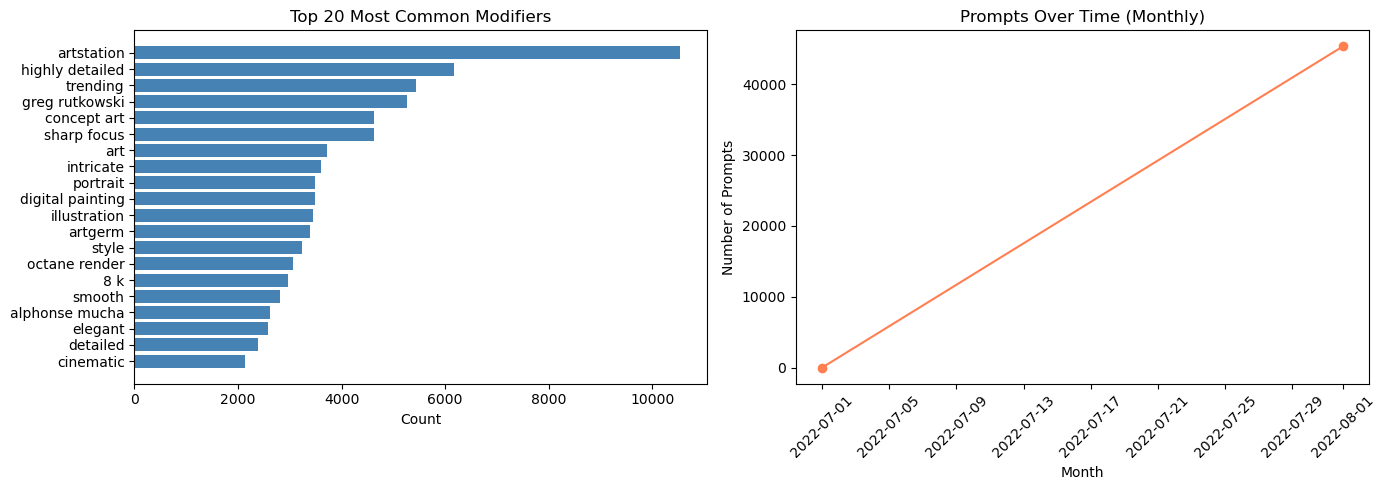

Saved: data/results_mlx/data_exploration.png


In [8]:
# Visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Top 20 modifiers bar chart
top_20 = modifier_counts.most_common(20)
mods, counts = zip(*top_20)
axes[0].barh(range(len(mods)), counts, color='steelblue')
axes[0].set_yticks(range(len(mods)))
axes[0].set_yticklabels(mods)
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')
axes[0].set_title('Top 20 Most Common Modifiers')

# 2. Prompts over time (monthly) - use valid_df with valid timestamps
monthly_counts_plot = valid_df.groupby(valid_df['datetime'].dt.to_period('M')).size()
monthly_counts_plot.index = monthly_counts_plot.index.to_timestamp()
axes[1].plot(monthly_counts_plot.index, monthly_counts_plot.values, marker='o', color='coral')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Prompts')
axes[1].set_title('Prompts Over Time (Monthly)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/results_mlx/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/results_mlx/data_exploration.png")

In [9]:
# Additional statistics about modifiers per prompt
print("=" * 60)
print("MODIFIERS PER PROMPT STATISTICS")
print("=" * 60)

mods_per_prompt = metadata_df['modifiers'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print(f"Average modifiers per prompt: {mods_per_prompt.mean():.2f}")
print(f"Median modifiers per prompt: {mods_per_prompt.median():.0f}")
print(f"Min modifiers per prompt: {mods_per_prompt.min()}")
print(f"Max modifiers per prompt: {mods_per_prompt.max()}")

print(f"\n{'=' * 60}")
print("DISTRIBUTION OF MODIFIERS PER PROMPT")
print("=" * 60)

mod_dist = mods_per_prompt.value_counts().sort_index()
for n_mods, count in mod_dist.head(15).items():
    pct = count / len(metadata_df) * 100
    bar = '█' * int(pct)
    print(f"  {n_mods:>2} modifiers: {count:>6} ({pct:>5.1f}%) {bar}")

# Export modifier statistics to CSV
print(f"\n{'=' * 60}")
print("EXPORTING STATISTICS")
print("=" * 60)

# Save top modifiers
top_modifiers_df = pd.DataFrame(modifier_counts.most_common(500), columns=['modifier', 'count'])
top_modifiers_df['percentage'] = top_modifiers_df['count'] / len(metadata_df) * 100
top_modifiers_df.to_csv('data/results_mlx/modifier_statistics.csv', index=False)
print(f"Saved: data/results_mlx/modifier_statistics.csv (top 500 modifiers)")

# Save historical modifiers
hist_mods_df = pd.DataFrame(sorted_hist_mods, columns=['modifier', 'count'])
hist_mods_df['percentage'] = hist_mods_df['count'] / len(metadata_df) * 100
hist_mods_df.to_csv('data/results_mlx/historical_modifiers.csv', index=False)
print(f"Saved: data/results_mlx/historical_modifiers.csv ({len(hist_mods_df)} modifiers)")

MODIFIERS PER PROMPT STATISTICS
Average modifiers per prompt: 9.56
Median modifiers per prompt: 8
Min modifiers per prompt: 0
Max modifiers per prompt: 87

DISTRIBUTION OF MODIFIERS PER PROMPT
   0 modifiers:      6 (  0.0%) 
   1 modifiers:   2138 (  4.3%) ████
   2 modifiers:   4055 (  8.1%) ████████
   3 modifiers:   4127 (  8.3%) ████████
   4 modifiers:   3557 (  7.1%) ███████
   5 modifiers:   3251 (  6.5%) ██████
   6 modifiers:   3036 (  6.1%) ██████
   7 modifiers:   2717 (  5.5%) █████
   8 modifiers:   2712 (  5.4%) █████
   9 modifiers:   2536 (  5.1%) █████
  10 modifiers:   2319 (  4.7%) ████
  11 modifiers:   2128 (  4.3%) ████
  12 modifiers:   2055 (  4.1%) ████
  13 modifiers:   1826 (  3.7%) ███
  14 modifiers:   1853 (  3.7%) ███

EXPORTING STATISTICS
Saved: data/results_mlx/modifier_statistics.csv (top 500 modifiers)
Saved: data/results_mlx/historical_modifiers.csv (22050 modifiers)


## 2. Load Model (MLX primary, Ollama fallback)

In [10]:
# Configuration
# Use the MLX-community pre-converted 3B model (fastest)
MODEL_ID = "mlx-community/Ministral-3-3B-Instruct-2512-4bit"
OLLAMA_MODEL = "ministral"  # Fallback model name for Ollama

USE_MLX = True  # Set to False to use Ollama instead
BATCH_SIZE_INFERENCE = 8  # Number of prompts to process in parallel

model = None
tokenizer = None

if USE_MLX:
    try:
        from mlx_lm import load, generate, batch_generate
        from huggingface_hub import snapshot_download

        print(f"Model: {MODEL_ID}")
        print(f"Batch size: {BATCH_SIZE_INFERENCE} prompts in parallel")
        print("=" * 60)

        # Download with visible progress bar
        print("\nStep 1/2: Downloading model (if not cached)...")

        local_path = snapshot_download(repo_id=MODEL_ID)

        print(f"\nModel cached at: {local_path}")
        print("\nStep 2/2: Loading model into memory...")

        # Load from the cached path
        model, tokenizer = load(local_path)

        print("=" * 60)
        print("Model loaded successfully via MLX!")

    except Exception as e:
        print(f"MLX loading failed: {e}")
        print("Falling back to Ollama...")
        USE_MLX = False

if not USE_MLX:
    try:
        import ollama
        ollama.list()
        print(f"Using Ollama with model: {OLLAMA_MODEL}")
    except Exception as e:
        raise RuntimeError(f"Neither MLX nor Ollama available: {e}")

Model: mlx-community/Ministral-3-3B-Instruct-2512-4bit
Batch size: 8 prompts in parallel

Step 1/2: Downloading model (if not cached)...


2026-03-18 17:15:31,949 - INFO - HTTP Request: GET https://huggingface.co/api/models/mlx-community/Ministral-3-3B-Instruct-2512-4bit/revision/main "HTTP/1.1 200 OK"


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]


Model cached at: /Users/fcl/.cache/huggingface/hub/models--mlx-community--Ministral-3-3B-Instruct-2512-4bit/snapshots/a962dcb09eee4169c890e544c9eb938f1113fdee

Step 2/2: Loading model into memory...
Model loaded successfully via MLX!


## 3. System Prompt

Adapted from the Claude version, with added requirement for a one-sentence justification.

In [11]:
SYSTEM_PROMPT = """Analyze if this image generation prompt contains a reference to the historical past.

Answer YES if the prompt contains:
- Historical figures (Napoleon, Caesar, Cleopatra, Marie Antoinette, etc.)
- Historical events (World War, Revolution, Cold War, etc.)
- Historical periods or eras (Victorian, Medieval, Renaissance, 1920s, Ancient Rome, etc.)
- Historical artists or their works (Da Vinci, Rembrandt, Michelangelo, etc.)
- Historical art movements (Baroque, Art Nouveau, Impressionism, etc.)
- Mythology and ancient legends (Greek gods, Norse mythology, Egyptian mythology, etc.)

Answer NO if the prompt:
- Only uses stylistic words (vintage, retro, sepia, old photograph)
- Only describes fictional/fantasy content (steampunk, cyberpunk, sci-fi)
- Only mentions living celebrities in modern context
- References extinct animals without historical context (dinosaurs, dodo)
- Is purely futuristic with no past reference

Format: [yes/no]: [one sentence reason]
"""

print("System prompt configured (balanced version v2)")
print(f"Prompt length: {len(SYSTEM_PROMPT)} characters")

System prompt configured (balanced version v2)
Prompt length: 966 characters


## 4. Classification Functions

In [12]:
from mlx_lm.sample_utils import make_sampler

# Create a deterministic sampler (temp=0 uses argmax)
greedy_sampler = make_sampler(temp=0.0)

def format_prompt_for_model(user_prompt: str) -> str:
    """Format the prompt using the tokenizer's chat template."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Analyze this prompt: {user_prompt}"}
    ]
    return tokenizer.apply_chat_template(
        messages, 
        tokenize=False, 
        add_generation_prompt=True
    )


def parse_response(response: str) -> tuple[str, str]:
    """Parse the model response into classification and justification."""
    response = response.strip()
    
    # Try to match the expected format: "yes: justification" or "no: justification"
    match = re.match(r'^(yes|no)\s*[:\-]\s*(.+)', response, re.IGNORECASE | re.DOTALL)
    
    if match:
        classification = match.group(1).lower()
        justification = match.group(2).strip()
        justification = justification.split('.')[0] + '.' if '.' in justification else justification
        return classification, justification
    
    # Fallback parsing
    response_lower = response.lower()
    if response_lower.startswith('yes'):
        return 'yes', response[3:].strip(' :-')
    elif response_lower.startswith('no'):
        return 'no', response[2:].strip(' :-')
    
    if 'yes' in response_lower[:50]:
        return 'yes', response
    elif 'no' in response_lower[:50]:
        return 'no', response
    
    logger.warning(f"Could not parse response: {response[:100]}")
    return 'error', response


def classify_prompt(prompt: str, max_tokens: int = 100) -> tuple[str, str, float]:
    """Classify a single prompt using MLX (for testing)."""
    formatted = format_prompt_for_model(prompt)
    
    start_time = time.time()
    response = generate(
        model,
        tokenizer,
        prompt=formatted,
        max_tokens=max_tokens,
        sampler=greedy_sampler,
    )
    generation_time = time.time() - start_time
    
    classification, justification = parse_response(response)
    return classification, justification, generation_time


def classify_batch(prompts: list[str], max_tokens: int = 60) -> list[dict]:
    """Classify a batch of prompts in parallel using MLX batch_generate.
    
    Returns:
        tuple: (list of result dicts, total_time)
    """
    # Format all prompts
    formatted_prompts = [format_prompt_for_model(p) for p in prompts]
    
    # Tokenize all prompts
    tokenized = [tokenizer.encode(p) for p in formatted_prompts]
    
    start_time = time.time()
    
    # Batch generate
    batch_response = batch_generate(
        model,
        tokenizer,
        prompts=tokenized,
        max_tokens=max_tokens,
    )
    
    total_time = time.time() - start_time
    time_per_prompt = total_time / len(prompts)
    
    # Parse all responses - use 'texts' attribute
    results = []
    for prompt, response_text in zip(prompts, batch_response.texts):
        classification, justification = parse_response(response_text)
        results.append({
            'prompt': prompt,
            'references_past': classification,
            'justification': justification,
            'generation_time': time_per_prompt
        })
    
    return results, total_time


print("Classification functions defined (with batch support)")

Classification functions defined (with batch support)


## 5. Load Dataset

In [13]:
# Configuration for validation phase
SAMPLE_SIZE = 100  # Start with 1000 for validation

# Load prompts WITH full metadata
print(f"Loading {SAMPLE_SIZE} prompts for validation (with metadata)...")

# Count total rows
total_rows = sum(1 for _ in open('data/prompts.csv')) - 1  # -1 for header
print(f"Total prompts in dataset: {total_rows:,}")

# Compute skip probability for random sampling
skip_prob = 1 - SAMPLE_SIZE / total_rows

# Load sample - both columns
np.random.seed(42)  # For reproducibility
prompts_df = pd.read_csv(
    'data/prompts.csv',
    skiprows=lambda x: x > 0 and np.random.random() < skip_prob,
    nrows=SAMPLE_SIZE
)

# Parse raw_data JSON into separate columns
def extract_metadata(raw_data_str):
    """Extract metadata fields from raw_data JSON."""
    try:
        data = json.loads(raw_data_str)
        discord_data = data.get('raw_discord_data', {})
        ts = discord_data.get('timestamp', 0)
        # Normalize timestamp to Unix float
        if isinstance(ts, str):
            try:
                ts = pd.Timestamp(ts).timestamp()
            except:
                ts = 0
        return pd.Series({
            'image_uri': discord_data.get('image_uri', ''),
            'timestamp': float(ts) if ts else 0,
            'modifiers': json.dumps(data.get('modifiers', [])),
            'width': discord_data.get('width', 0),
            'height': discord_data.get('height', 0),
        })
    except (json.JSONDecodeError, TypeError):
        return pd.Series({
            'image_uri': '', 'timestamp': 0, 'modifiers': '[]',
            'width': 0, 'height': 0,
        })

print("Parsing metadata...")
metadata_cols = prompts_df['raw_data'].apply(extract_metadata)
prompts_df = pd.concat([prompts_df[['prompt']], metadata_cols], axis=1)

# Convert timestamp to datetime
prompts_df['datetime'] = pd.to_datetime(prompts_df['timestamp'], unit='s', errors='coerce')
prompts_df.loc[prompts_df['timestamp'] == 0, 'datetime'] = pd.NaT

# Clean prompts
prompts_df = prompts_df.dropna(subset=['prompt'])
prompts_df['prompt'] = prompts_df['prompt'].astype(str).str.strip()
prompts_df = prompts_df[prompts_df['prompt'] != '']

# Also keep a plain list for backward compatibility with classification functions
prompts_list = prompts_df['prompt'].tolist()

print(f"Loaded {len(prompts_df)} prompts with metadata")
print(f"Columns: {list(prompts_df.columns)}")
print(f"Date range: {prompts_df['datetime'].min()} to {prompts_df['datetime'].max()}")
print(f"\nFirst 3 prompts:")
for i, (_, row) in enumerate(prompts_df.head(3).iterrows()):
    print(f"  {i+1}. {row['prompt'][:70]}... | {row['datetime']}")

Loading 100 prompts for validation (with metadata)...
Total prompts in dataset: 10,789,407
Parsing metadata...
Loaded 88 prompts with metadata
Columns: ['prompt', 'image_uri', 'timestamp', 'modifiers', 'width', 'height', 'datetime']
Date range: 2022-08-07 04:25:49 to 2022-08-17 10:13:58

First 3 prompts:
  1. jungle by greg rutkowski... | 2022-08-13 06:51:19
  2. mr. blobby, portrait, militaristic... | 2022-08-15 04:32:37
  3. vanishing point, retro futurist city in the sky next to bigs cumulonim... | 2022-08-15 16:25:22


## 6. Test Single Classification

Test the model on a single prompt to verify everything works.

In [14]:
# Test with a single prompt
test_prompt = prompts_list[0] if prompts_list else "Napoleon Bonaparte leading his army across the Alps"

print(f"Testing with prompt: {test_prompt}")
print("="*60)

classification, justification, gen_time = classify_prompt(test_prompt)

print(f"Classification: {classification}")
print(f"Justification: {justification}")
print(f"Generation time: {gen_time:.2f}s")
print("="*60)

# Estimate time for full validation
estimated_total_time = gen_time * len(prompts_list)
print(f"\nEstimated time for {len(prompts_list)} prompts: {estimated_total_time/60:.1f} minutes")

Testing with prompt: jungle by greg rutkowski
Classification: no
Justification: **NO**: [The prompt describes a stylistic aesthetic (jungle) without referencing historical figures, events, periods, artists, movements, or mythology.]

*(Note: Even if "greg rutkowski" is a modern artist, the prompt itself is purely descriptive of a setting, not tied to historical past.)*
Generation time: 1.33s

Estimated time for 88 prompts: 1.9 minutes


## 6b. (Optional) Purge Previous Results

Run this cell to delete previous validation results and start fresh.

In [15]:
# OPTIONAL: Run this cell to delete previous results and start fresh
# Comment out or skip this cell if you want to resume from previous results
import os

RESULTS_FILE = "data/results_mlx/validation_results.csv"

if os.path.exists(RESULTS_FILE):
    os.remove(RESULTS_FILE)
    print(f"Deleted: {RESULTS_FILE}")
    print("Previous results purged. You can now re-run the validation.")
else:
    print(f"No results file found at {RESULTS_FILE}")
    print("Nothing to purge.")

Deleted: data/results_mlx/validation_results.csv
Previous results purged. You can now re-run the validation.


## 7. Run Validation (1000 prompts)

Process the validation sample with progress tracking and incremental saves.

In [16]:
# Configuration
SAVE_EVERY = 100  # Save results every N prompts
RESULTS_FILE = "data/results_mlx/validation_results.csv"

# Check for existing results (for resuming)
start_idx = 0
existing_results = []

if os.path.exists(RESULTS_FILE):
    existing_df = pd.read_csv(RESULTS_FILE)
    start_idx = len(existing_df)
    existing_results = existing_df.to_dict('records')
    print(f"Resuming from index {start_idx} ({start_idx} prompts already processed)")

# Build list of rows to process (prompt + metadata)
rows_to_process = prompts_df.iloc[start_idx:].reset_index(drop=True)

# Process prompts in BATCHES for speed
results = existing_results.copy()

print(f"Processing {len(rows_to_process)} prompts in batches of {BATCH_SIZE_INFERENCE}...")
print("="*60)

start_time = time.time()
total_batches = (len(rows_to_process) + BATCH_SIZE_INFERENCE - 1) // BATCH_SIZE_INFERENCE

for batch_idx in tqdm(range(total_batches), desc="Batch processing"):
    batch_start = batch_idx * BATCH_SIZE_INFERENCE
    batch_end = min(batch_start + BATCH_SIZE_INFERENCE, len(rows_to_process))
    batch_rows = rows_to_process.iloc[batch_start:batch_end]
    batch_prompts = batch_rows['prompt'].tolist()
    
    try:
        batch_results, batch_time = classify_batch(batch_prompts)
        
        # Enrich results with metadata
        for result, (_, row) in zip(batch_results, batch_rows.iterrows()):
            result['image_uri'] = row['image_uri']
            result['timestamp'] = row['timestamp']
            result['datetime'] = str(row['datetime']) if pd.notna(row['datetime']) else ''
            result['modifiers'] = row['modifiers']
            result['width'] = row['width']
            result['height'] = row['height']
        
        results.extend(batch_results)
        
    except Exception as e:
        logger.error(f"Error in batch {batch_idx}: {e}")
        for _, row in batch_rows.iterrows():
            try:
                classification, justification, gen_time = classify_prompt(row['prompt'])
                results.append({
                    'prompt': row['prompt'],
                    'references_past': classification,
                    'justification': justification,
                    'generation_time': gen_time,
                    'image_uri': row['image_uri'],
                    'timestamp': row['timestamp'],
                    'datetime': str(row['datetime']) if pd.notna(row['datetime']) else '',
                    'modifiers': row['modifiers'],
                    'width': row['width'],
                    'height': row['height'],
                })
            except Exception as e2:
                results.append({
                    'prompt': row['prompt'],
                    'references_past': 'error',
                    'justification': str(e2),
                    'generation_time': 0,
                    'image_uri': row['image_uri'],
                    'timestamp': row['timestamp'],
                    'datetime': str(row['datetime']) if pd.notna(row['datetime']) else '',
                    'modifiers': row['modifiers'],
                    'width': row['width'],
                    'height': row['height'],
                })
    
    # Save incrementally
    if (batch_idx + 1) % (SAVE_EVERY // BATCH_SIZE_INFERENCE) == 0 or batch_idx == total_batches - 1:
        pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)
        elapsed = time.time() - start_time
        prompts_done = len(results) - len(existing_results)
        rate = prompts_done / elapsed if elapsed > 0 else 0
        logger.info(f"Saved {len(results)} results. Rate: {rate:.1f} prompts/sec")

# Final save
results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_FILE, index=False)

total_time = time.time() - start_time
prompts_processed = len(results) - len(existing_results)
print("="*60)
print(f"Completed! Total time: {total_time/60:.1f} minutes")
print(f"Prompts processed: {prompts_processed}")
print(f"Average rate: {prompts_processed/total_time:.2f} prompts/sec")
print(f"Columns in results: {list(results_df.columns)}")

Processing 88 prompts in batches of 8...


Batch processing:   0%|          | 0/11 [00:00<?, ?it/s]

2026-03-18 17:17:00,520 - INFO - Saved 88 results. Rate: 1.6 prompts/sec


Completed! Total time: 0.9 minutes
Prompts processed: 88
Average rate: 1.57 prompts/sec
Columns in results: ['prompt', 'references_past', 'justification', 'generation_time', 'image_uri', 'timestamp', 'datetime', 'modifiers', 'width', 'height']


## 8. Validation Results Summary

In [17]:
# Load and analyze results
results_df = pd.read_csv(RESULTS_FILE)

print("=" * 60)
print("VALIDATION RESULTS SUMMARY")
print("=" * 60)

total = len(results_df)
yes_count = (results_df['references_past'] == 'yes').sum()
no_count = (results_df['references_past'] == 'no').sum()
error_count = (results_df['references_past'] == 'error').sum()

print(f"Total prompts processed: {total}")
print(f"References to past (yes): {yes_count} ({yes_count/total*100:.2f}%)")
print(f"No reference (no): {no_count} ({no_count/total*100:.2f}%)")
print(f"Errors: {error_count} ({error_count/total*100:.2f}%)")

print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)

avg_time = results_df['generation_time'].mean()
print(f"Average generation time: {avg_time:.2f}s per prompt")
print(f"Throughput: {3600/avg_time:.0f} prompts/hour")

# Estimate for full dataset
full_dataset_hours = (10_000_000 * avg_time) / 3600
print(f"\nEstimated time for 10M prompts: {full_dataset_hours:.0f} hours ({full_dataset_hours/24:.1f} days)")

VALIDATION RESULTS SUMMARY
Total prompts processed: 88
References to past (yes): 13 (14.77%)
No reference (no): 75 (85.23%)
Errors: 0 (0.00%)

PERFORMANCE METRICS
Average generation time: 0.64s per prompt
Throughput: 5653 prompts/hour

Estimated time for 10M prompts: 1769 hours (73.7 days)


In [18]:
# Show sample results with justifications
print("\n" + "=" * 60)
print("SAMPLE RESULTS WITH JUSTIFICATIONS")
print("=" * 60)

# Show some 'yes' examples
yes_samples = results_df[results_df['references_past'] == 'yes'].head(5)
print("\n--- Prompts WITH references to the past ---")
for _, row in yes_samples.iterrows():
    print(f"\nPrompt: {row['prompt'][:100]}{'...' if len(row['prompt']) > 100 else ''}")
    print(f"Justification: {row['justification']}")

# Show some 'no' examples
no_samples = results_df[results_df['references_past'] == 'no'].head(5)
print("\n--- Prompts WITHOUT references to the past ---")
for _, row in no_samples.iterrows():
    print(f"\nPrompt: {row['prompt'][:100]}{'...' if len(row['prompt']) > 100 else ''}")
    print(f"Justification: {row['justification']}")


SAMPLE RESULTS WITH JUSTIFICATIONS

--- Prompts WITH references to the past ---

Prompt: filmic extreme wide shot dutch angle movie still 4k UHD 35mm film color photograph of a science lab ...
Justification: **[yes/no]:** This prompt references a **historical period/era (1980s horror film)**, though it does not explicitly name a specific event, figure, or movement.

*(Note: While the setting is fictionalized, the "1980s horror film" style

Prompt: Goth girl by Mario Testino, oil painting by Lawrence Alma-Tadema, masterpiece
Justification: **YES**: The prompt references **historical artists** (Mario Testino, Lawrence Alma-Tadema) and **historical art movements/periods** (Alma-Tadema’s work is tied to the **Victorian era** and **Romanticism**), as well as a **

Prompt: school girl reading a book, school uniform, seifuku, pleated miniskirt, overknee socks, battle angel...
Justification: **[yes/no]: The prompt references **historical figures (Alita of Battle Angel Alita, a fictional but s

---

## 9. Clustering with BERTopic

Cluster the prompts (those with historical references) to discover thematic patterns.

In [19]:
# Install BERTopic dependencies (uncomment and run if needed)
# Note: typing_extensions must be >= 4.10.0 for TypeIs support
%pip install --upgrade typing_extensions bertopic sentence-transformers umap-learn hdbscan plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 227.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 212.3 MB/s eta 0:00:0000:01
  Attempting uninstall: plotly
    Found existing installation: plotly 6.5.2
    Uninstalling plotly-6.5.2:
      Successfully uninstalled plotly-6.5.2
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.2
    Uninstalling sentence-transformers-5.2.2:
      Successfully uninstalled sentence-transformers-5.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
Note: you may need to restart the kernel 

In [20]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px

# Load results and filter to "yes" prompts (historical references)
results_df = pd.read_csv("data/results_mlx/validation_results.csv")
historical_prompts = results_df[results_df['references_past'] == 'yes']['prompt'].tolist()

print(f"Clustering {len(historical_prompts)} prompts with historical references...")

# Use sentence-transformers for embeddings (runs on CPU, fast for small datasets)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Create vectorizer with stopword removal for better topic words
vectorizer_model = CountVectorizer(stop_words='english', ngram_range=(1, 2))

# Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=2,  # Small clusters allowed for validation set
    verbose=True
)

# Fit the model
topics, probs = topic_model.fit_transform(historical_prompts)

print(f"\nFound {len(set(topics)) - 1} topics (excluding outliers)")
print(f"Outliers (topic -1): {topics.count(-1)} prompts")

2026-03-18 17:17:16,250 - INFO - Use pytorch device_name: mps
2026-03-18 17:17:16,250 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-03-18 17:17:16,430 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:17:16,446 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"


Clustering 13 prompts with historical references...


2026-03-18 17:17:16,569 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:17:16,585 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-18 17:17:16,709 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:17:16,724 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-18 17:17:16,847 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/README.md "HTTP/1.1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-18 17:17:17,623 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:17:17,638 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-03-18 17:17:17,768 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:17:17,784 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transfor

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-18 17:17:20,374 - BERTopic - Embedding - Completed ✓
2026-03-18 17:17:20,374 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-18 17:17:22,451 - BERTopic - Dimensionality - Completed ✓
2026-03-18 17:17:22,452 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-18 17:17:22,454 - BERTopic - Cluster - Completed ✓
2026-03-18 17:17:22,455 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-18 17:17:22,460 - BERTopic - Representation - Completed ✓



Found 2 topics (excluding outliers)
Outliers (topic -1): 2 prompts


In [21]:
# Show topic info - top words per cluster
print("=" * 60)
print("TOPICS DISCOVERED")
print("=" * 60)

topic_info = topic_model.get_topic_info()
print(topic_info[['Topic', 'Count', 'Name']].to_string())

# Show representative prompts for each topic
print("\n" + "=" * 60)
print("REPRESENTATIVE PROMPTS PER TOPIC")
print("=" * 60)

for topic_id in sorted(set(topics)):
    if topic_id == -1:
        continue  # Skip outliers
    
    topic_prompts = [p for p, t in zip(historical_prompts, topics) if t == topic_id]
    topic_words = topic_model.get_topic(topic_id)
    
    print(f"\n--- Topic {topic_id} ({len(topic_prompts)} prompts) ---")
    print(f"Top words: {', '.join([w for w, _ in topic_words[:5]])}")
    print("Sample prompts:")
    for p in topic_prompts[:3]:
        print(f"  - {p[:80]}{'...' if len(p) > 80 else ''}")

TOPICS DISCOVERED
   Topic  Count                                      Name
0     -1      2  -1_film_apocalypse_view emma_emma watson
1      0      6            0_school_masterpiece_book_girl
2      1      5               1_wall_style_painting_table

REPRESENTATIVE PROMPTS PER TOPIC

--- Topic 0 (6 prompts) ---
Top words: school, masterpiece, book, girl, alita
Sample prompts:
  - Goth girl by Mario Testino, oil painting by Lawrence Alma-Tadema, masterpiece
  - school girl reading a book, school uniform, seifuku, pleated miniskirt, overknee...
  - raspberries in a forest by Vincent van Gogh

--- Topic 1 (5 prompts) ---
Top words: wall, style, painting, table, award
Sample prompts:
  - filmic extreme wide shot dutch angle movie still 4k UHD 35mm film color photogra...
  - PORTRAIT Painting of a blond male Venus Apollo. LONG CURLY blond hair. Sharp ang...
  - a picture of an ancient Ethiopian church painting of the devil, wall mural


### 9.1 Visualizations

In [22]:
# Interactive topic visualization - Intertopic Distance Map
fig_topics = topic_model.visualize_topics()
fig_topics.show()

# Save as HTML
fig_topics.write_html("data/results_mlx/topics_map.html")
print("Saved: data/results_mlx/topics_map.html")

ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
# Document visualization - 2D scatter plot of prompts colored by topic
# Get embeddings for visualization
embeddings = embedding_model.encode(historical_prompts)

# Reduce to 2D with UMAP (same as BERTopic uses internally)
from umap import UMAP
umap_model = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = umap_model.fit_transform(embeddings)

# Create dataframe for visualization
viz_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'topic': [str(t) for t in topics],
    'prompt': [p[:100] + '...' if len(p) > 100 else p for p in historical_prompts]
})

# Interactive scatter plot
fig = px.scatter(
    viz_df, x='x', y='y', color='topic',
    hover_data=['prompt'],
    title='Prompts with Historical References - Clustered by Semantic Similarity',
    width=900, height=700
)
fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

# Save as HTML
fig.write_html("data/results_mlx/prompts_clusters.html")
print("Saved: data/results_mlx/prompts_clusters.html")

### 9.2 Temporal Analysis

Analyze the proportion of historical prompts over time and track topic evolution.

**Granularity**: Change `TEMPORAL_GRANULARITY` to `'W'` (weekly) or `'D'` (daily).

In [ ]:
# Temporal analysis of historical references
import plotly.graph_objects as go

# --- Configuration ---
TEMPORAL_GRANULARITY = 'W'  # 'M' = monthly, 'W' = weekly, 'D' = daily
GRANULARITY_LABELS = {'M': 'Monthly', 'W': 'Weekly', 'D': 'Daily'}

# Load results with metadata
results_df = pd.read_csv("data/results_mlx/validation_results.csv")

# Parse datetime
results_df['datetime'] = pd.to_datetime(results_df['datetime'], errors='coerce')
valid_mask = results_df['datetime'].notna()
temporal_df = results_df[valid_mask].copy()

print(f"Prompts with valid timestamps: {len(temporal_df):,} / {len(results_df):,}")
print(f"Granularity: {GRANULARITY_LABELS.get(TEMPORAL_GRANULARITY, TEMPORAL_GRANULARITY)}")

# Create period column
temporal_df['period'] = temporal_df['datetime'].dt.to_period(TEMPORAL_GRANULARITY)

# Count total and historical prompts per period
period_total = temporal_df.groupby('period').size()
period_historical = temporal_df[temporal_df['references_past'] == 'yes'].groupby('period').size()

# Combine into a DataFrame
temporal_stats = pd.DataFrame({
    'total': period_total,
    'historical': period_historical,
}).fillna(0).astype(int)

temporal_stats['pct_historical'] = (temporal_stats['historical'] / temporal_stats['total'] * 100).round(2)

print(f"\n{'=' * 60}")
print(f"HISTORICAL REFERENCES OVER TIME ({GRANULARITY_LABELS.get(TEMPORAL_GRANULARITY, TEMPORAL_GRANULARITY)})")
print(f"{'=' * 60}")
for period, row in temporal_stats.iterrows():
    bar = '█' * int(row['pct_historical'])
    print(f"  {period}  {row['historical']:>4}/{row['total']:>5} ({row['pct_historical']:>5.1f}%) {bar}")

# Line chart: % historical prompts over time
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=[str(p) for p in temporal_stats.index],
    y=temporal_stats['pct_historical'],
    mode='lines+markers',
    name='% Historical',
    line=dict(color='coral', width=2),
    marker=dict(size=8),
    hovertemplate='%{x}<br>%{y:.1f}% historical<br>%{customdata[0]} / %{customdata[1]} prompts',
    customdata=temporal_stats[['historical', 'total']].values,
))

fig.update_layout(
    title=f'Proportion of Historical Prompts Over Time ({GRANULARITY_LABELS.get(TEMPORAL_GRANULARITY)})',
    xaxis_title='Period',
    yaxis_title='% Historical Prompts',
    width=900, height=400,
)
fig.show()
fig.write_html("data/results_mlx/temporal_historical_pct.html")
print("Saved: data/results_mlx/temporal_historical_pct.html")

In [ ]:
# Topic evolution over time - Streamgraph
# Shows how each topic's share evolves across time periods

# Get historical prompts with their topics and timestamps
hist_mask = temporal_df['references_past'] == 'yes'
hist_temporal = temporal_df[hist_mask].copy()

# We need the topic assignments from BERTopic
# Match by prompt text to get topic IDs
prompt_to_topic = dict(zip(historical_prompts, topics))
hist_temporal['topic'] = hist_temporal['prompt'].map(prompt_to_topic)
hist_temporal = hist_temporal.dropna(subset=['topic'])
hist_temporal['topic'] = hist_temporal['topic'].astype(int)

# Get topic names from the model
topic_names = {}
for topic_id in sorted(set(topics)):
    if topic_id == -1:
        topic_names[-1] = "Outliers"
    else:
        words = topic_model.get_topic(topic_id)
        topic_names[topic_id] = f"T{topic_id}: {', '.join([w for w, _ in words[:3]])}"

hist_temporal['topic_name'] = hist_temporal['topic'].map(topic_names)

# Count topics per period
topic_period = hist_temporal.groupby(['period', 'topic_name']).size().reset_index(name='count')
topic_period['period_str'] = topic_period['period'].astype(str)

# Pivot for streamgraph
pivot = topic_period.pivot(index='period_str', columns='topic_name', values='count').fillna(0)

print(f"Topics tracked over {len(pivot)} periods")
print(f"Topics: {list(pivot.columns)}")

# Streamgraph using plotly stacked area
fig = go.Figure()
for col in pivot.columns:
    if col == "Outliers":
        continue  # Skip outliers for cleaner visualization
    fig.add_trace(go.Scatter(
        x=pivot.index,
        y=pivot[col],
        name=col,
        mode='lines',
        stackgroup='one',
        hovertemplate='%{x}<br>' + col + ': %{y} prompts',
    ))

fig.update_layout(
    title=f'Topic Evolution Over Time ({GRANULARITY_LABELS.get(TEMPORAL_GRANULARITY)}) - Streamgraph',
    xaxis_title='Period',
    yaxis_title='Number of Prompts',
    width=1000, height=500,
    showlegend=True,
    legend=dict(font=dict(size=9)),
)
fig.show()
fig.write_html("data/results_mlx/topic_evolution_streamgraph.html")
print("Saved: data/results_mlx/topic_evolution_streamgraph.html")

# Also show as table
print(f"\n{'=' * 60}")
print("TOPIC COUNTS PER PERIOD")
print("=" * 60)
print(pivot.to_string())

## 9. Compare with Claude Results (Optional)

If you have existing Claude API results, compare them here.

In [ ]:
"""
# Optional: Compare with Claude results if available
CLAUDE_RESULTS_FILE = "data/results_claude/past_references_complete_results.csv"

if os.path.exists(CLAUDE_RESULTS_FILE):
    claude_df = pd.read_csv(CLAUDE_RESULTS_FILE)
    
    # Find matching prompts
    merged = results_df.merge(
        claude_df[['prompt', 'references_past']],
        on='prompt',
        how='inner',
        suffixes=('_mlx', '_claude')
    )
    
    if len(merged) > 0:
        agreement = (merged['references_past_mlx'] == merged['references_past_claude']).sum()
        print(f"\n=== COMPARISON WITH CLAUDE RESULTS ===")
        print(f"Matching prompts found: {len(merged)}")
        print(f"Agreement rate: {agreement/len(merged)*100:.2f}%")
        
        # Show disagreements
        disagreements = merged[merged['references_past_mlx'] != merged['references_past_claude']]
        if len(disagreements) > 0:
            print(f"\nDisagreements ({len(disagreements)}):")
            for _, row in disagreements.head(5).iterrows():
                print(f"\nPrompt: {row['prompt'][:80]}...")
                print(f"  MLX: {row['references_past_mlx']} | Claude: {row['references_past_claude']}")
    else:
        print("No matching prompts found between datasets")
else:
    print(f"No Claude results file found at {CLAUDE_RESULTS_FILE}")
    print("Skipping comparison.")
"""

# FULL DATASET CONFIGURATION
# Uncomment and run this section when ready to process the full dataset

"""
FULL_RESULTS_FILE = "data/results_mlx/full_results.csv"
CHECKPOINT_INTERVAL = 1000  # Save every N prompts

# Load full dataset with metadata
print("Loading full dataset with metadata...")
full_df = pd.read_csv('data/prompts.csv')

# Parse metadata
print("Parsing JSON metadata (this may take a while for 10M rows)...")
metadata_cols = full_df['raw_data'].apply(extract_metadata)
full_df = pd.concat([full_df[['prompt']], metadata_cols], axis=1)
full_df['datetime'] = pd.to_datetime(full_df['timestamp'], unit='s', errors='coerce')
full_df.loc[full_df['timestamp'] == 0, 'datetime'] = pd.NaT

# Clean
full_df = full_df.dropna(subset=['prompt'])
full_df['prompt'] = full_df['prompt'].astype(str).str.strip()
full_df = full_df[full_df['prompt'] != '']

print(f"Total prompts to process: {len(full_df):,}")

# Check for existing checkpoint
start_idx = 0
existing_results = []

if os.path.exists(FULL_RESULTS_FILE):
    existing_df = pd.read_csv(FULL_RESULTS_FILE)
    start_idx = len(existing_df)
    existing_results = existing_df.to_dict('records')
    print(f"Resuming from index {start_idx:,}")

# Process in batches
results = existing_results.copy()
rows_to_process = full_df.iloc[start_idx:].reset_index(drop=True)
total_batches = (len(rows_to_process) + BATCH_SIZE_INFERENCE - 1) // BATCH_SIZE_INFERENCE

for batch_idx in tqdm(range(total_batches), desc="Processing full dataset"):
    batch_start = batch_idx * BATCH_SIZE_INFERENCE
    batch_end = min(batch_start + BATCH_SIZE_INFERENCE, len(rows_to_process))
    batch_rows = rows_to_process.iloc[batch_start:batch_end]
    batch_prompts = batch_rows['prompt'].tolist()
    
    try:
        batch_results, batch_time = classify_batch(batch_prompts)
        for result, (_, row) in zip(batch_results, batch_rows.iterrows()):
            result['image_uri'] = row['image_uri']
            result['timestamp'] = row['timestamp']
            result['datetime'] = str(row['datetime']) if pd.notna(row['datetime']) else ''
            result['modifiers'] = row['modifiers']
            result['width'] = row['width']
            result['height'] = row['height']
        results.extend(batch_results)
    except Exception as e:
        logger.error(f"Error in batch {batch_idx}: {e}")
        for _, row in batch_rows.iterrows():
            try:
                classification, justification, gen_time = classify_prompt(row['prompt'])
                results.append({
                    'prompt': row['prompt'], 'references_past': classification,
                    'justification': justification, 'generation_time': gen_time,
                    'image_uri': row['image_uri'], 'timestamp': row['timestamp'],
                    'datetime': str(row['datetime']) if pd.notna(row['datetime']) else '',
                    'modifiers': row['modifiers'], 'width': row['width'], 'height': row['height'],
                })
            except Exception as e2:
                results.append({
                    'prompt': row['prompt'], 'references_past': 'error',
                    'justification': str(e2), 'generation_time': 0,
                    'image_uri': row['image_uri'], 'timestamp': row['timestamp'],
                    'datetime': str(row['datetime']) if pd.notna(row['datetime']) else '',
                    'modifiers': row['modifiers'], 'width': row['width'], 'height': row['height'],
                })
    
    # Checkpoint
    if (batch_idx + 1) % (CHECKPOINT_INTERVAL // BATCH_SIZE_INFERENCE) == 0 or batch_idx == total_batches - 1:
        pd.DataFrame(results).to_csv(FULL_RESULTS_FILE, index=False)
        logger.info(f"Checkpoint: {len(results):,} prompts processed")

print(f"Done! Processed {len(results):,} prompts")
"""

print("Full dataset processing is commented out.")
print("Uncomment the code above when ready to process all 10M prompts.")

In [ ]:
# FULL DATASET CONFIGURATION
# Uncomment and run this section when ready to process the full dataset


FULL_RESULTS_FILE = "data/results_mlx/full_results.csv"
CHECKPOINT_INTERVAL = 1000  # Save every N prompts

# Load full dataset
print("Loading full dataset...")
full_prompts_df = pd.read_csv('data/prompts.csv', usecols=[0])
full_prompts = full_prompts_df.iloc[:, 0].dropna().tolist()
full_prompts = [str(p).strip() for p in full_prompts if str(p).strip()]

print(f"Total prompts to process: {len(full_prompts):,}")

# Check for existing checkpoint
start_idx = 0
existing_results = []

if os.path.exists(FULL_RESULTS_FILE):
    existing_df = pd.read_csv(FULL_RESULTS_FILE)
    start_idx = len(existing_df)
    existing_results = existing_df.to_dict('records')
    print(f"Resuming from index {start_idx:,}")

# Process
results = existing_results.copy()

for i, prompt in enumerate(tqdm(full_prompts[start_idx:], desc="Processing full dataset")):
    try:
        classification, justification, gen_time = classify_prompt(prompt)
        results.append({
            'prompt': prompt,
            'references_past': classification,
            'justification': justification,
            'generation_time': gen_time
        })
    except Exception as e:
        results.append({
            'prompt': prompt,
            'references_past': 'error',
            'justification': str(e),
            'generation_time': 0
        })
    
    # Checkpoint
    if (start_idx + i + 1) % CHECKPOINT_INTERVAL == 0:
        pd.DataFrame(results).to_csv(FULL_RESULTS_FILE, index=False)
        logger.info(f"Checkpoint: {len(results):,} prompts processed")

# Final save
pd.DataFrame(results).to_csv(FULL_RESULTS_FILE, index=False)
print(f"Done! Processed {len(results):,} prompts")

## 10. Evaluation of Classification Results

Inspect the full results to evaluate whether the yes/no judgements are correct, and cluster the justifications to understand the reasoning patterns.

In [ ]:
# Load full results (filter out errors)
full_df = pd.read_csv(FULL_RESULTS_FILE)
full_df = full_df[full_df["references_past"].isin(["yes", "no"])].reset_index(drop=True)
print(f"Total valid results: {len(full_df):,}")
print(f"Yes: {(full_df["references_past"]=="yes").sum():,}")
print(f"No: {(full_df["references_past"]=="no").sum():,}")
print()

# First 100 YES lines
yes_df = full_df[full_df["references_past"] == "yes"].reset_index(drop=True)
print("=" * 80)
print(f"FIRST 100 YES ENTRIES (out of {len(yes_df):,})")
print("=" * 80)
for i, row in yes_df.head(100).iterrows():
    print(f"
[{i+1}] PROMPT: {row["prompt"][:150]}")
    justif = row["justification"][:300] if pd.notna(row["justification"]) else "N/A"
    print(f"    JUSTIFICATION: {justif}")


In [ ]:
# First 100 NO lines
no_df = full_df[full_df["references_past"] == "no"].reset_index(drop=True)
print("=" * 80)
print(f"FIRST 100 NO ENTRIES (out of {len(no_df):,})")
print("=" * 80)
for i, row in no_df.head(100).iterrows():
    print(f"
[{i+1}] PROMPT: {row["prompt"][:150]}")
    justif = row["justification"][:300] if pd.notna(row["justification"]) else "N/A"
    print(f"    JUSTIFICATION: {justif}")


In [ ]:
# Cluster YES justifications using BERTopic
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# Clean justifications
yes_justifications = yes_df["justification"].dropna().tolist()
print(f"Clustering {len(yes_justifications):,} YES justifications...")

# Use a lightweight sentence transformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

vectorizer = CountVectorizer(stop_words="english", min_df=5, ngram_range=(1, 2))
topic_model_yes = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer,
    nr_topics="auto",
    min_topic_size=50,
    verbose=True
)

topics_yes, probs_yes = topic_model_yes.fit_transform(yes_justifications)

print("
" + "=" * 80)
print("YES JUSTIFICATION CLUSTERS")
print("=" * 80)
topic_info_yes = topic_model_yes.get_topic_info()
print(f"
Number of topics: {len(topic_info_yes)}")
print()
for _, row in topic_info_yes.head(20).iterrows():
    print(f"Topic {row["Topic"]}: {row["Count"]:,} docs | {row["Name"]}")
    # Show representative words
    topic_words = topic_model_yes.get_topic(row["Topic"])
    if topic_words:
        words = ", ".join([w for w, _ in topic_words[:8]])
        print(f"  Keywords: {words}")
    print()


In [ ]:
# Cluster NO justifications using BERTopic
no_justifications = no_df["justification"].dropna().tolist()
# Sample if too large (1M+ is expensive to embed)
import random
MAX_CLUSTER_SAMPLE = 100_000
if len(no_justifications) > MAX_CLUSTER_SAMPLE:
    random.seed(42)
    no_justifications_sample = random.sample(no_justifications, MAX_CLUSTER_SAMPLE)
    print(f"Sampled {MAX_CLUSTER_SAMPLE:,} from {len(no_justifications):,} NO justifications for clustering")
else:
    no_justifications_sample = no_justifications
    print(f"Clustering {len(no_justifications_sample):,} NO justifications...")

vectorizer_no = CountVectorizer(stop_words="english", min_df=5, ngram_range=(1, 2))
topic_model_no = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_no,
    nr_topics="auto",
    min_topic_size=50,
    verbose=True
)

topics_no, probs_no = topic_model_no.fit_transform(no_justifications_sample)

print("
" + "=" * 80)
print("NO JUSTIFICATION CLUSTERS")
print("=" * 80)
topic_info_no = topic_model_no.get_topic_info()
print(f"
Number of topics: {len(topic_info_no)}")
print()
for _, row in topic_info_no.head(20).iterrows():
    print(f"Topic {row["Topic"]}: {row["Count"]:,} docs | {row["Name"]}")
    topic_words = topic_model_no.get_topic(row["Topic"])
    if topic_words:
        words = ", ".join([w for w, _ in topic_words[:8]])
        print(f"  Keywords: {words}")
    print()
